In [1]:
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

In [2]:
def load_data():
    train_features, train_labels = joblib.load("train_features.pkl")
    val_features, val_labels     = joblib.load("val_features.pkl")
    test_features, test_labels   = joblib.load("test_features.pkl")
    return train_features, train_labels, val_features, val_labels, test_features, test_labels

train_features, train_labels, val_features, val_labels, test_features, test_labels = load_data()

This loads the .pkl files you saved during feature extraction. Each file contains (features, labels).


In [8]:
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

def preprocess_data(train_features, train_labels,
                    val_features, val_labels,
                    test_features, test_labels):
    # Encode labels across all splits
    label_encoder = LabelEncoder()
    y_train = label_encoder.fit_transform(train_labels)
    y_val   = label_encoder.transform(val_labels)
    y_test  = label_encoder.transform(test_labels)
    class_names = label_encoder.classes_

    # Scale features (fit on train only, transform val/test)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(train_features)
    X_val_scaled   = scaler.transform(val_features)
    X_test_scaled  = scaler.transform(test_features)

    # PCA (retain 98% variance, fit on train only)
    print(f"Features before PCA: {X_train_scaled.shape[1]}")
    pca = PCA(n_components=0.98, random_state=42)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_val_pca   = pca.transform(X_val_scaled)
    X_test_pca  = pca.transform(X_test_scaled)
    print(f"Features after PCA: {X_train_pca.shape[1]}")

    return X_train_pca, y_train, X_val_pca, y_val, X_test_pca, y_test, class_names, pca

- Labels are encoded into integers.
- Train and validation sets are combined.
- Features are standardized (mean=0, variance=1).
- PCA reduces dimensionality while retaining 98% of variance.


In [9]:
X_train, y_train, X_val, y_val, X_test, y_test, class_names, pca = preprocess_data(
    train_features, train_labels,
    val_features, val_labels,
    test_features, test_labels
)

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)
print("Classes:", class_names)

Features before PCA: 651
Features after PCA: 476
Train: (14729, 476) (14729,)
Val: (4906, 476) (4906,)
Test: (4948, 476) (4948,)
Classes: ['Achnanthidium jackii' 'Achnanthidium minutissimum' 'Amphora pediculus'
 'Cocconeis placentula' 'Discostella pseudostelligera' 'Navicula gregaria'
 'Navicula lanceolata' 'Nitzschia dissipata' 'Nitzschia soratensis'
 'Planothidium lanceolatum']


This executes preprocessing and prints dataset shapes and class names.

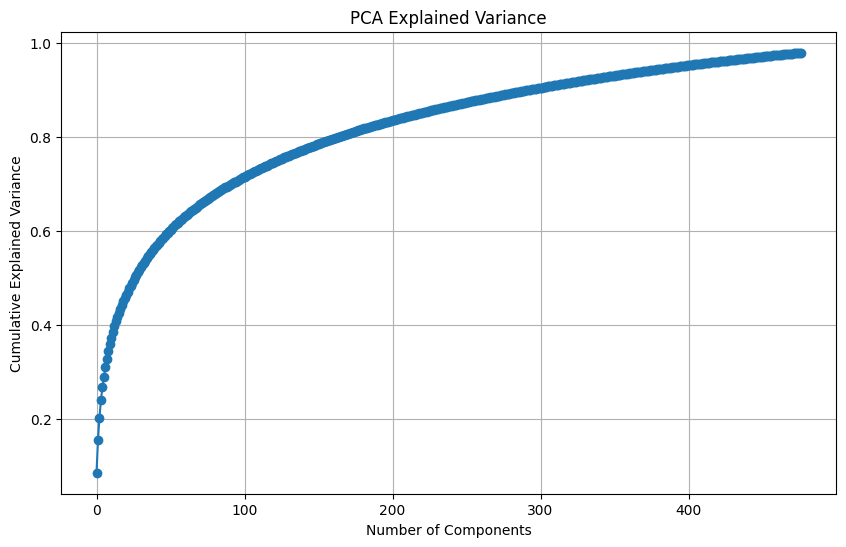

In [5]:
plt.figure(figsize=(10,6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid(True)
plt.show()

This plot shows how much variance is explained as you add more PCA components. It helps confirm that 98% variance is retained

C:\Users\Yaswanth\AppData\Local\Temp\ipykernel_22584\336108000.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette="viridis")


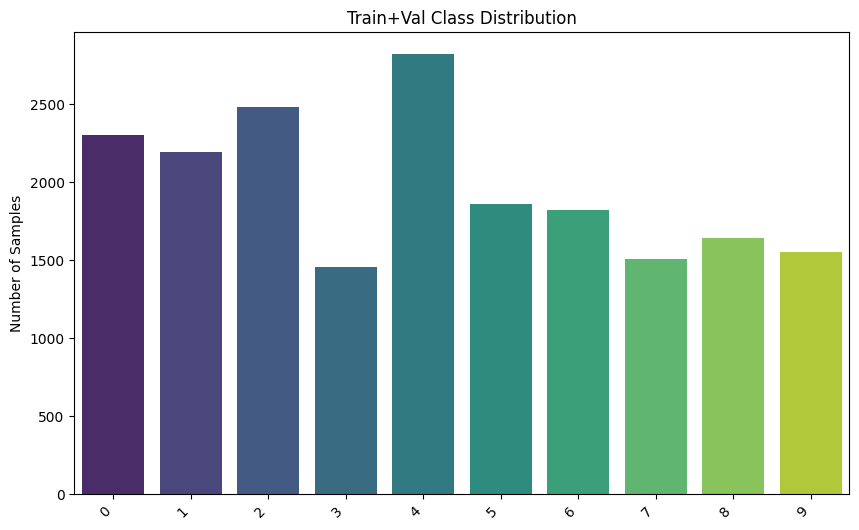

C:\Users\Yaswanth\AppData\Local\Temp\ipykernel_22584\336108000.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette="viridis")


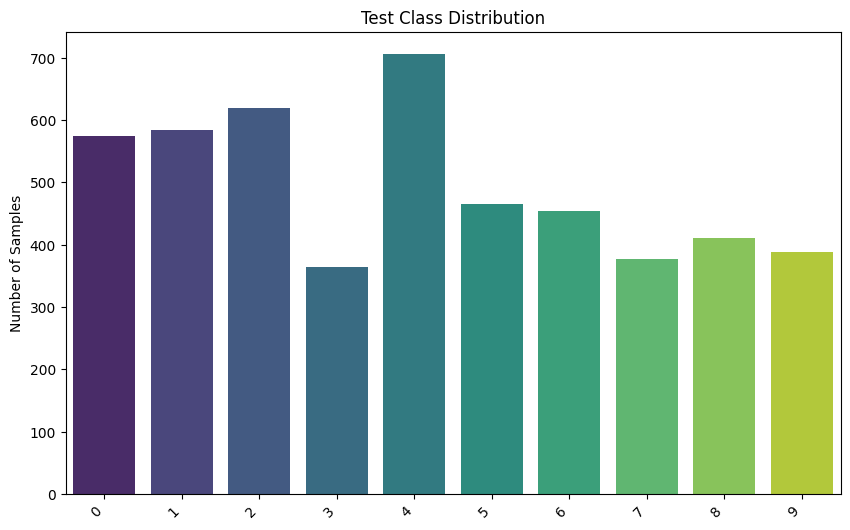

In [6]:
import collections

def plot_class_distribution(labels, split_name):
    counts = collections.Counter(labels)
    plt.figure(figsize=(10,6))
    sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette="viridis")
    plt.xticks(rotation=45, ha="right")
    plt.title(f"{split_name} Class Distribution")
    plt.ylabel("Number of Samples")
    plt.show()

plot_class_distribution(y_train, "Train+Val")
plot_class_distribution(y_test, "Test")

This shows how balanced your dataset is across species after preprocessing.

In [10]:
# Save train, val, test splits
joblib.dump((X_train, y_train), "X_train_preprocessed.pkl")
joblib.dump((X_val, y_val), "X_val_preprocessed.pkl")   # if you keep val separate
joblib.dump((X_test, y_test), "X_test_preprocessed.pkl")

# Save class names
joblib.dump(class_names, "class_names.pkl")

['class_names.pkl']